# EDA — Gas Monitoring Dataset

**Goal:** Predict `Activity Level` (Low / Moderate / High) from indoor gas and environment sensor readings.

1. Load & see the dataset
2. Assess data quality (missing values, dirty labels, impossible readings, class imbalance)
3. Clean the data
4. Explore feature distributions and their relationship to the target
5. Engineer new features
6. Summarise findings and hand off to the ML pipeline


---
## 1. Setup

Import libraries, configure display settings, and load the dataset from SQLite.

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "axes.titlesize": 13, "axes.labelsize": 11})
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
PALETTE = {"Low Activity": "#4C9BE8", "Moderate Activity": "#F5A623", "High Activity": "#E85C5C"}
CLASS_ORDER = ["Low Activity", "Moderate Activity", "High Activity"]

#Load data
DB_PATH = "data/gas_monitoring.db"

with sqlite3.connect(DB_PATH) as conn:
    df_raw = pd.read_sql("SELECT * FROM gas_monitoring", conn)

print(f"Loaded: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
df_raw.head()

Loaded: 10,000 rows x 14 columns


,Time of Day,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor,Session ID,HVAC Operation Mode,Ambient Light Level,Activity Level
0,morning,19.630,53.830,125.486,571.089,478.555,735.850,654.625,565.052,2.000,7241,off,very_dim,Low Activity
1,morning,292.810,53.690,126.343,575.790,491.955,740.283,655.734,557.078,1.000,7241,ventilation_only,bright,Low Activity
2,morning,19.620,54.250,126.561,585.543,505.561,737.113,649.962,558.065,1.000,7241,eco_mode,NaN,Low Activity
3,morning,20.100,50.480,113.505,597.450,515.142,744.021,676.150,600.222,NaN,7241,eco_mode,very_bright,High Activity
4,morning,19.890,48.420,92.766,613.655,535.665,770.265,720.274,625.731,1.000,7241,heating_active,moderate,LowActivity


---
## 2. Dataset Overview

**Purpose:** Understand the dataset like what columns exist, their data types, and basic statistics

In [2]:
# Column types and a quick statistical summary
print("Numerical columns :", df_raw.select_dtypes(include='number').columns.tolist())
print("Categorical columns:", df_raw.select_dtypes(include='object').columns.tolist())
df_raw.describe().round(2)

Numerical columns : ['Temperature', 'Humidity', 'CO2_InfraredSensor', 'CO2_ElectroChemicalSensor', 'MetalOxideSensor_Unit1', 'MetalOxideSensor_Unit2', 'MetalOxideSensor_Unit3', 'MetalOxideSensor_Unit4', 'CO_GasSensor', 'Session ID']
Categorical columns: ['Time of Day', 'HVAC Operation Mode', 'Ambient Light Level', 'Activity Level']


C:\Users\mingh\AppData\Local\Temp\ipykernel_4972\1059886279.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print("Categorical columns:", df_raw.select_dtypes(include='object').columns.tolist())


,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor,Session ID
count,"10,000.000","8,072.000","10,000.000","10,000.000","10,000.000","8,590.000","10,000.000","10,000.000","9,166.000","10,000.000"
mean,42.240,51.640,109.860,578.630,470.930,728.350,680.490,612.250,1.290,"5,427.920"
std,73.970,21.330,33.790,22.570,51.460,29.140,55.950,43.170,0.780,"2,590.840"
min,6.900,-49.870,-17.470,408.600,286.830,611.170,456.670,412.790,0.000,"1,374.000"
25%,18.940,47.660,96.660,559.350,440.040,709.660,658.520,585.510,1.000,"3,074.000"
50%,20.510,51.390,112.810,579.360,469.150,726.750,679.910,609.530,1.000,"5,214.000"
75%,23.170,53.840,124.540,595.570,494.770,744.880,703.520,636.010,2.000,"7,395.000"
max,307.070,198.900,237.870,637.900,632.890,807.730,906.210,736.110,4.000,"9,658.000"


### Data Dictionary

| Column | Type | Planned use |
|---|---|---|
| `Session ID` | Identifier | **Drop** — not a sensor feature |
| `Time of Day` | Categorical | Keep — one-hot encode |
| `Temperature` | Numerical | Clean impossible values, then impute |
| `Humidity` | Numerical | Clean impossible values, then impute |
| `CO2_InfraredSensor` | Numerical | Keep — check for redundancy with electrochemical sensor |
| `CO2_ElectroChemicalSensor` | Numerical | Keep — likely strong predictor |
| `MetalOxideSensor_Unit1–4` | Numerical | Keep — VOC/gas readings, expected to be important |
| `CO_GasSensor` | Numerical | Keep — has missing values, impute |
| `HVAC Operation Mode` | Categorical | Clean dirty labels, then one-hot encode |
| `Ambient Light Level` | Categorical | Impute missing, then one-hot encode |
| `Activity Level` | **Target** | Clean inconsistent labels → 3 final classes |

>`describe()` already shows Temperature values above 300°C and negative Humidity — physically impossible for an indoor sensor. These will be handled in Section 3.


---
## 3. Data Quality Assessment

**Purpose:** Identify every data quality issue before any modelling. Each data quality issue is addressed with a data cleaning strategy

Issues checked:
- Missing values
- Inconsistent / dirty labels
- Impossible sensor readings
- Class imbalance in the target


### 3.1 Missing Values


In [3]:
# Count and percentage of missing values per column
missing_count = df_raw.isnull().sum()
missing_pct   = (missing_count / len(df_raw) * 100).round(2)

missing_df = pd.DataFrame({"Missing Count": missing_count, "Missing %": missing_pct})
missing_df = missing_df[missing_df["Missing Count"] > 0].sort_values("Missing %", ascending=False)
missing_df

,Missing Count,Missing %
Humidity,1928,19.280
MetalOxideSensor_Unit2,1410,14.100
Ambient Light Level,1054,10.540
CO_GasSensor,834,8.340


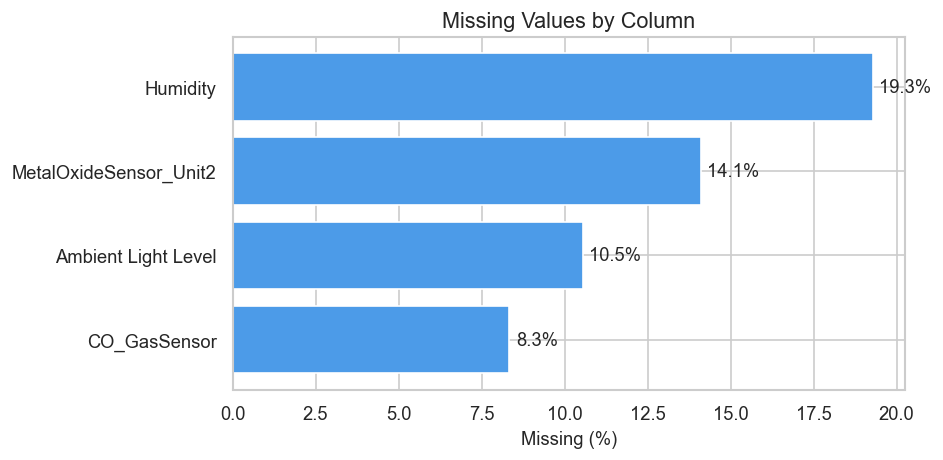

In [4]:
# Bar chart — easier to compare missing % at a glance
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(missing_df.index, missing_df["Missing %"], color="#4C9BE8", edgecolor="white")

for bar, val in zip(bars, missing_df["Missing %"]):
    ax.text(val + 0.2, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}%", va="center", fontsize=11)

ax.set_xlabel("Missing (%)")
ax.set_title("Missing Values by Column")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

**Findings:**
- 4 columns have missing data, ranging from 8.3% (`CO_GasSensor`) to 19.3% (`Humidity`).
- Missing rates are spread across all activity classes (not concentrated in one class), so dropping rows would create bias.

**Cleaning strategy:**
- **Numerical columns** → median imputation (chosen over mean because extreme sensor readings skew the mean).
- **Categorical columns** → mode imputation.
- Imputers must be fitted on **training data only** in the pipeline to prevent data leakage.


### 3.2 Inconsistent Labels


In [5]:
# Inspect raw label variants before cleaning
print("=== Activity Level (raw) ===")
print(df_raw["Activity Level"].value_counts())

print("\n=== HVAC Operation Mode (raw) ===")
print(df_raw["HVAC Operation Mode"].value_counts())

=== Activity Level (raw) ===
Activity Level
Low Activity         5244
Moderate Activity    2812
High Activity        1095
ModerateActivity      326
Low_Activity          285
LowActivity           238
Name: count, dtype: int64

=== HVAC Operation Mode (raw) ===
HVAC Operation Mode
cooling_active      1502
maintenance_mode    1500
heating_active      1468
off                 1456
eco_mode            1452
ventilation_only    1394
COOLING_ACTIVE       112
ECO_MODE             112
MAINTENANCE_MODE     106
Off                  103
HEATING_ACTIVE        98
VENTILATION_ONLY      98
OFF                   93
Cooling_Active        64
Eco_mode              56
Eco_Mode              53
Heating_active        50
Cooling_active        50
Maintenance_Mode      49
Maintenance_mode      48
Ventilation_Only      47
Ventilation_only      45
Heating_Active        44
Name: count, dtype: int64


In [6]:
#normalise Activity Level
activity_map = {
    "Low Activity":      "Low Activity",
    "Low_Activity":      "Low Activity",
    "LowActivity":       "Low Activity",
    "Moderate Activity": "Moderate Activity",
    "ModerateActivity":  "Moderate Activity",
    "High Activity":     "High Activity",
}

df = df_raw.copy()
df["Activity Level"] = df["Activity Level"].map(activity_map)

#Normalise HVAC Operation Mode 
df["HVAC Operation Mode"] = (
    df["HVAC Operation Mode"]
    .str.strip()
    .str.lower()
    .str.replace("_", " ", regex=False)
)

#check whether cleaning is successful or not
expected_activity = {"Low Activity", "Moderate Activity", "High Activity"}
expected_hvac     = {"cooling active", "eco mode", "heating active",
                     "maintenance mode", "off", "ventilation only"}

assert set(df["Activity Level"].dropna().unique()) == expected_activity, "Unexpected Activity Level labels found"
assert set(df["HVAC Operation Mode"].dropna().unique()) == expected_hvac, "Unexpected HVAC labels found"
assert df["Activity Level"].isna().sum() == 0, "Activity Level should have no missing values"

print("Label cleaning passed all checks.")
print(f"Activity Level classes : {sorted(expected_activity)}")
print(f"HVAC modes             : {sorted(expected_hvac)}")

Label cleaning passed all checks.
Activity Level classes : ['High Activity', 'Low Activity', 'Moderate Activity']
HVAC modes             : ['cooling active', 'eco mode', 'heating active', 'maintenance mode', 'off', 'ventilation only']


**Findings:**
- `Activity Level` had 6 raw variants referring to only 3 real classes — casing and underscore differences.
- `HVAC Operation Mode` had 23 raw variants that reduce to 6 real modes after normalisation.

**Why this matters:** Without cleaning, the model would treat spelling differences as separate classes


### 3.3 Impossible Sensor Values


In [7]:
# Identify physically impossible readings
# Temperature: values 250–350 are Kelvin readings (≈ 16–77°C) — not sensor errors
# Values genuinely outside any plausible range (< 0 or > 60°C after conversion) are errors
temp_kelvin      = df[(df["Temperature"] > 200) & (df["Temperature"] < 400)]  # Kelvin band
hum_impossible   = df[(df["Humidity"] < 0) | (df["Humidity"] > 100)]

print(f"Temperature in Kelvin range (200–400 K) : {len(temp_kelvin):,} rows ({len(temp_kelvin)/len(df)*100:.1f}%)")
print(f"Sample Kelvin values → converted to °C  : {(temp_kelvin['Temperature'].head(5) - 273.15).round(2).tolist()}")
print(f"Humidity out of 0–100%                  : {len(hum_impossible):,} rows ({len(hum_impossible)/len(df)*100:.1f}%)")


Temperature in Kelvin range (200–400 K) : 795 rows (8.0%)
Sample Kelvin values → converted to °C  : [19.66, 19.44, 19.5, 19.02, 21.89]
Humidity out of 0–100%                  : 414 rows (4.1%)


**Findings:**
- 795 temperature readings fall in the 289–307 range — these are **Kelvin readings**, not sensor errors.
  Converting them: 289 K = 15.9°C, 295 K = 21.9°C, 307 K = 33.9°C — all perfectly valid indoor temperatures.
  Treating them as errors and imputing would silently discard 795 real data points.
- 414 humidity readings fall outside the physical 0–100% range — these are genuine sensor errors.
- Gas sensor spikes are **not** removed — sudden gas changes may genuinely signal high activity.

**Cleaning strategy:**
- **Temperature:** Convert Kelvin readings (> 200) to Celsius by subtracting 273.15. After conversion, any remaining values outside 0–60°C are set to NaN and median-imputed.
- **Humidity:** Set values outside 0–100% to NaN, then median-impute.


### 3.4 Class Distribution & Imbalance


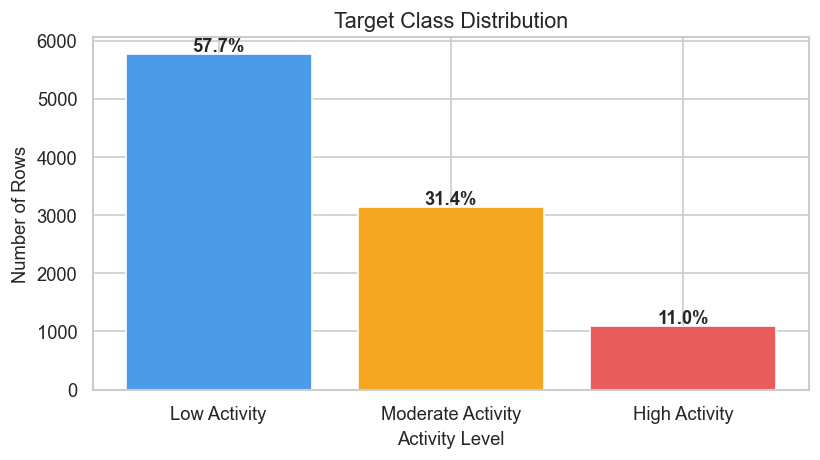

Activity Level
Low Activity         5767
Moderate Activity    3138
High Activity        1095


In [8]:
# Count rows/activity class after label cleaning
class_counts = df["Activity Level"].value_counts().reindex(CLASS_ORDER)
class_pct    = (class_counts / class_counts.sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(7, 4))
for i, (label, count) in enumerate(class_counts.items()):
    ax.bar(label, count, color=PALETTE[label], edgecolor="white")
    ax.text(i, count + 50, f"{class_pct[label]:.1f}%", ha="center", fontweight="bold", fontsize=11)

ax.set_title("Target Class Distribution")
ax.set_ylabel("Number of Rows")
ax.set_xlabel("Activity Level")
plt.tight_layout()
plt.show()

print(class_counts.to_string())

**Findings:**

| Class | Count | % |
|---|---:|---:|
| Low Activity | 5,767 | 57.7% |
| Moderate Activity | 3,138 | 31.4% |
| High Activity | 1,095 | 10.9% |

The target is imbalanced — a naive model that always predicts `Low Activity` achieves 57.7% accuracy without learning anything useful.

**Pipeline implications:**
- Use **stratified train/test split** to preserve class proportions.
- Report **weighted F1** (primary metric) and **macro F1** to ensure the minority class is not ignored.
- Test `class_weight='balanced'` during model tuning.


---
## 4. Data Cleaning

**Purpose:** Apply all cleaning decisions identified in Section 3 to produce `df_clean`, the dataset used for all further analysis.


In [9]:
df_clean = df.copy()

# STEP 1 — Convert Kelvin temperature readings to Celsius
# Values in the 200–400 range are Kelvin (289 K = ~16°C, 307 K = ~34°C — valid indoor temps)
# Subtracting 273.15 converts them correctly instead of discarding real data
kelvin_mask = df_clean["Temperature"] > 200
df_clean.loc[kelvin_mask, "Temperature"] = df_clean.loc[kelvin_mask, "Temperature"] - 273.15
print(f"Converted {kelvin_mask.sum():,} Kelvin readings to Celsius.")

# STEP 2 — Replace any remaining physically impossible values with NaN
# After Kelvin conversion, any Temperature outside 0–60°C or Humidity outside 0–100% is a true error
df_clean.loc[(df_clean["Temperature"] < 0) | (df_clean["Temperature"] > 60), "Temperature"] = None
df_clean.loc[(df_clean["Humidity"] < 0) | (df_clean["Humidity"] > 100), "Humidity"] = None

# STEP 3 — Median-impute all remaining missing numerical values
# Median is chosen over mean because right-skewed gas sensor readings inflate the mean
# Imputers must be fitted on training data only in the pipeline — here we use the full cleaned set for EDA
numerical_to_impute = ["Temperature", "Humidity", "MetalOxideSensor_Unit2", "CO_GasSensor"]
for col in numerical_to_impute:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# STEP 4 — Mode-impute missing categorical values
df_clean["Ambient Light Level"] = df_clean["Ambient Light Level"].fillna(
    df_clean["Ambient Light Level"].mode()[0]
)

# Verify no missing values remain
remaining = df_clean.isnull().sum().sum()
assert remaining == 0, f"Expected 0 missing values, found {remaining}"
print(f"Missing values remaining : {remaining}")
print(f"Clean dataset shape      : {df_clean.shape}")
print(f"Temperature range after cleaning: {df_clean['Temperature'].min():.1f}°C – {df_clean['Temperature'].max():.1f}°C")


Converted 795 Kelvin readings to Celsius.
Missing values remaining : 0
Clean dataset shape      : (10000, 14)
Temperature range after cleaning: 6.9°C – 34.3°C


---
## 5. Univariate Analysis

**Purpose:** Examine each feature's distribution independently to understand its shape, range, and central tendency. This confirms the cleaning worked and informs scaling and encoding decisions.


### 5.1 Sensor Distributions (post-cleaning)


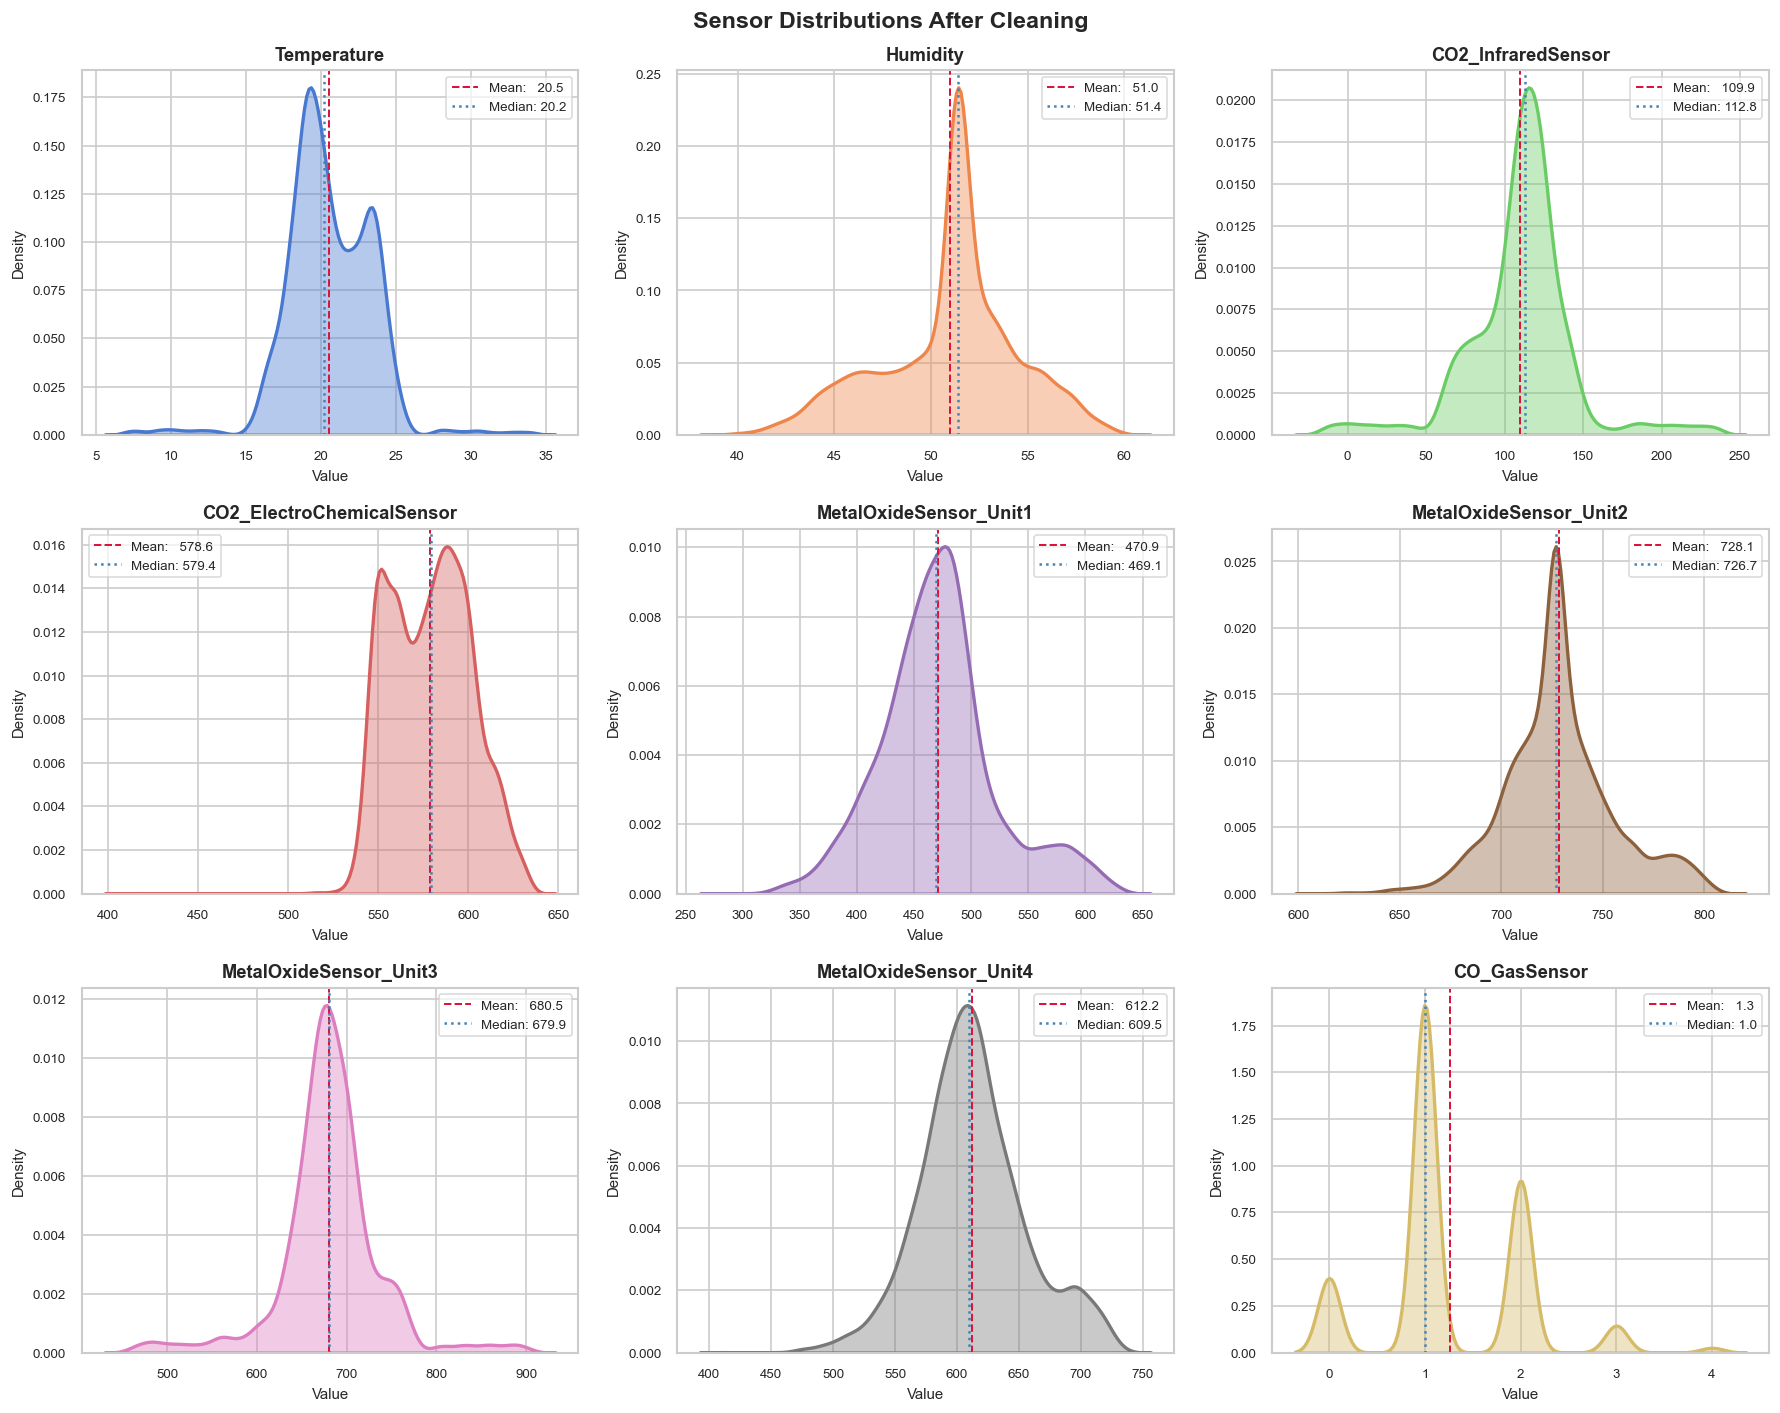

In [10]:
sensor_cols = [
    "Temperature", "Humidity",
    "CO2_InfraredSensor", "CO2_ElectroChemicalSensor",
    "MetalOxideSensor_Unit1", "MetalOxideSensor_Unit2",
    "MetalOxideSensor_Unit3", "MetalOxideSensor_Unit4",
    "CO_GasSensor"
]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()
colors = sns.color_palette("muted", len(sensor_cols))

for i, col in enumerate(sensor_cols):
    ax = axes[i]
    data = df_clean[col].dropna()

    sns.kdeplot(data, ax=ax, color=colors[i], fill=True, alpha=0.4, linewidth=2)
    ax.axvline(data.mean(),   color="crimson",   linestyle="--", linewidth=1.2,
               label=f"Mean:   {data.mean():.1f}")
    ax.axvline(data.median(), color="steelblue", linestyle=":",  linewidth=1.5,
               label=f"Median: {data.median():.1f}")

    ax.set_title(col, fontsize=11, fontweight="bold")
    ax.set_xlabel("Value", fontsize=9)
    ax.set_ylabel("Density", fontsize=9)
    ax.legend(fontsize=8, framealpha=0.7)
    ax.tick_params(labelsize=8)

plt.suptitle("Sensor Distributions After Cleaning", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

**Findings:**
- Temperature now shows a realistic indoor range after Kelvin conversion and cleaning — no more values above 40°C.
- Humidity now stays within 0–100% after removing out-of-range sensor errors.
- CO2 and Metal Oxide sensors are right-skewed: most readings cluster at lower values but occasional spikes occur — consistent with bursts of activity.
- When Mean > Median, the distribution is right-skewed, which confirms median imputation was the right choice over mean.
- `CO_GasSensor` appears more discrete (stepped values), suggesting it may have been rounded or binned at the sensor level.
- Because sensors are on very different scales, **standardisation (e.g. StandardScaler) is needed** before training distance-based or linear models.


### 5.2 Categorical Feature Distributions


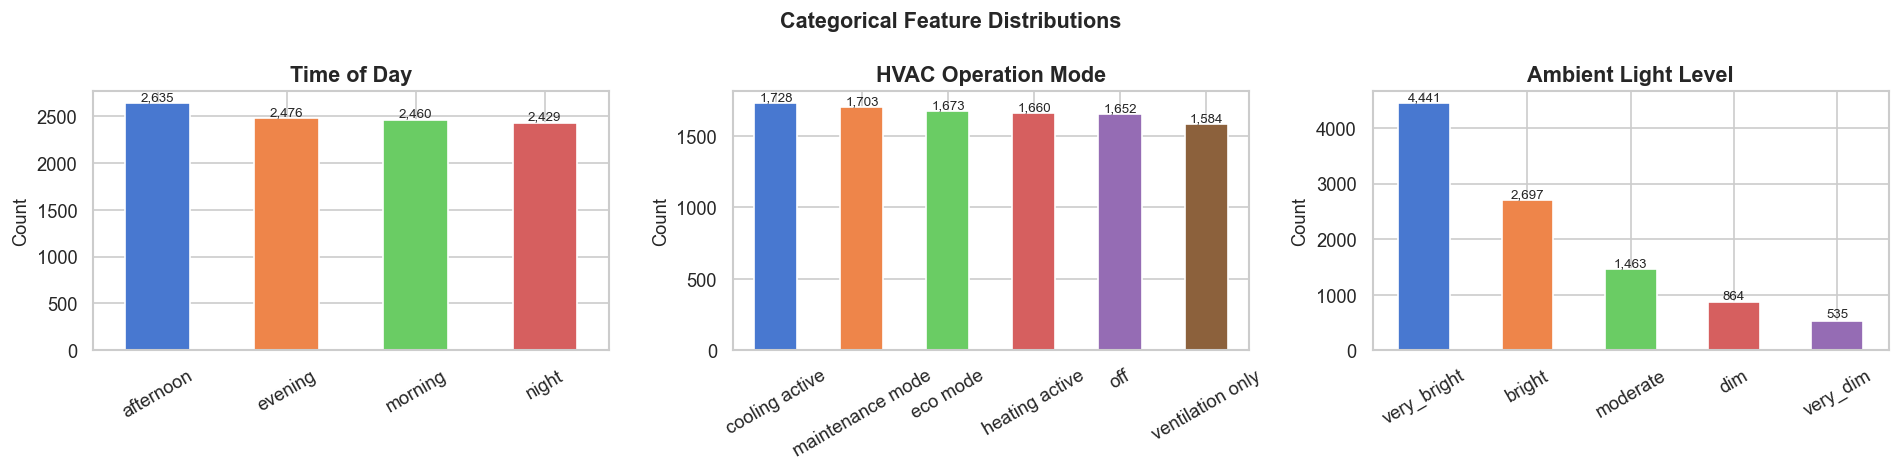

In [11]:
cat_cols = ["Time of Day", "HVAC Operation Mode", "Ambient Light Level"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col in zip(axes, cat_cols):
    counts = df_clean[col].value_counts()
    counts.plot(kind="bar", ax=ax,
                color=sns.color_palette("muted", len(counts)),
                edgecolor="white")
    ax.set_title(col, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=30)
    for p in ax.patches:
        ax.annotate(f"{int(p.get_height()):,}",
                    (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha="center", va="bottom", fontsize=8)

plt.suptitle("Categorical Feature Distributions", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

**Findings:**
- `Time of Day` is evenly spread across morning, afternoon, evening, and night — no dominant period.
- `HVAC Operation Mode` is reasonably balanced after label cleaning.
- `Ambient Light Level` skews toward brighter values, which may connect to daytime activity.



---
## 6. Bivariate Analysis — Features vs Target

**Purpose:** Examine how each feature relates to `Activity Level`. This reveals which sensors are most useful for prediction and how difficult the classification task is.


### 6.1 Sensor Readings by Activity Level


C:\Users\mingh\AppData\Local\Temp\ipykernel_4972\3228442847.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\mingh\AppData\Local\Temp\ipykernel_4972\3228442847.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\mingh\AppData\Local\Temp\ipykernel_4972\3228442847.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\mingh\AppData\Local\Temp\ipykernel_4972\3228442847.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and 

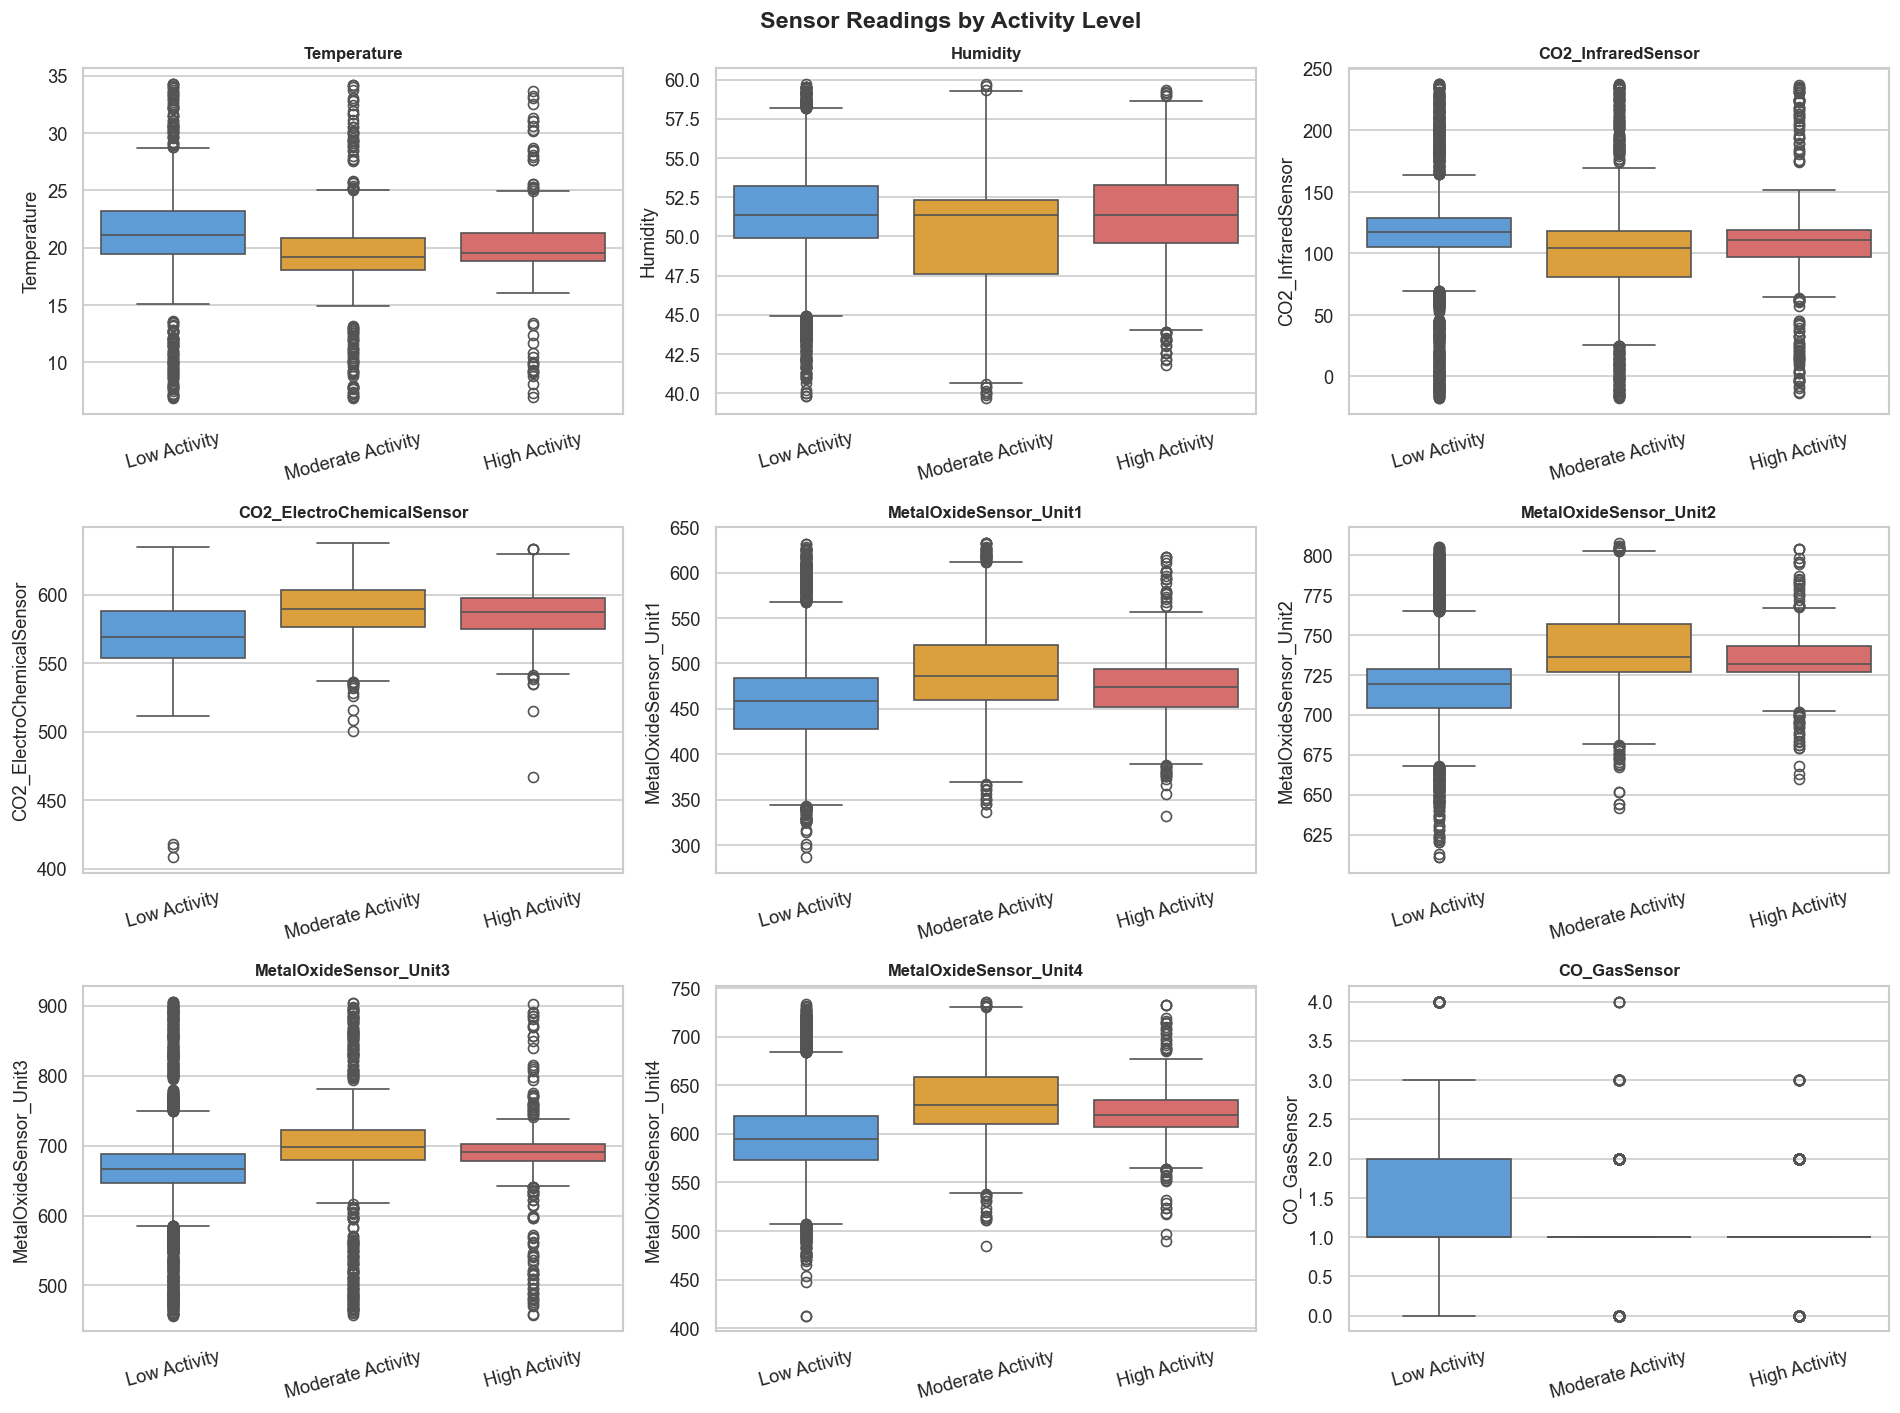

In [12]:
# Box plots show the median and spread per class — useful for spotting class separation
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(sensor_cols):
    ax = axes[i]
    sns.boxplot(
        data=df_clean, x="Activity Level", y=col,
        order=CLASS_ORDER, palette=PALETTE, ax=ax
    )
    ax.set_title(col, fontsize=10, fontweight="bold")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=15)

plt.suptitle("Sensor Readings by Activity Level", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

**Findings:**
- `MetalOxideSensor_Unit2` and `MetalOxideSensor_Unit4` show the clearest median shift across the three activity classes — these are the strongest individual predictors.
- `CO2_ElectroChemicalSensor` also increases with activity level, which makes physical sense: more movement and breathing raises CO2.
- `CO_GasSensor` shows an **inverse** pattern — CO decreases with higher activity. This is a useful contrasting signal.
- `Temperature` and `Humidity` medians overlap heavily across all three classes — they are weak predictors on their own.
- After Kelvin conversion and cleaning, `Temperature` shows a realistic indoor range of ~10–35°C. The medians across all three activity classes are nearly identical, confirming Temperature has no meaningful relationship with Activity Level and is not expected to be an important model feature.
- Low and Moderate Activity boxes overlap significantly across most sensors, indicating the classification boundary is **not linear** — non-linear models are more appropriate.


### 6.2 Categorical Features vs Activity Level


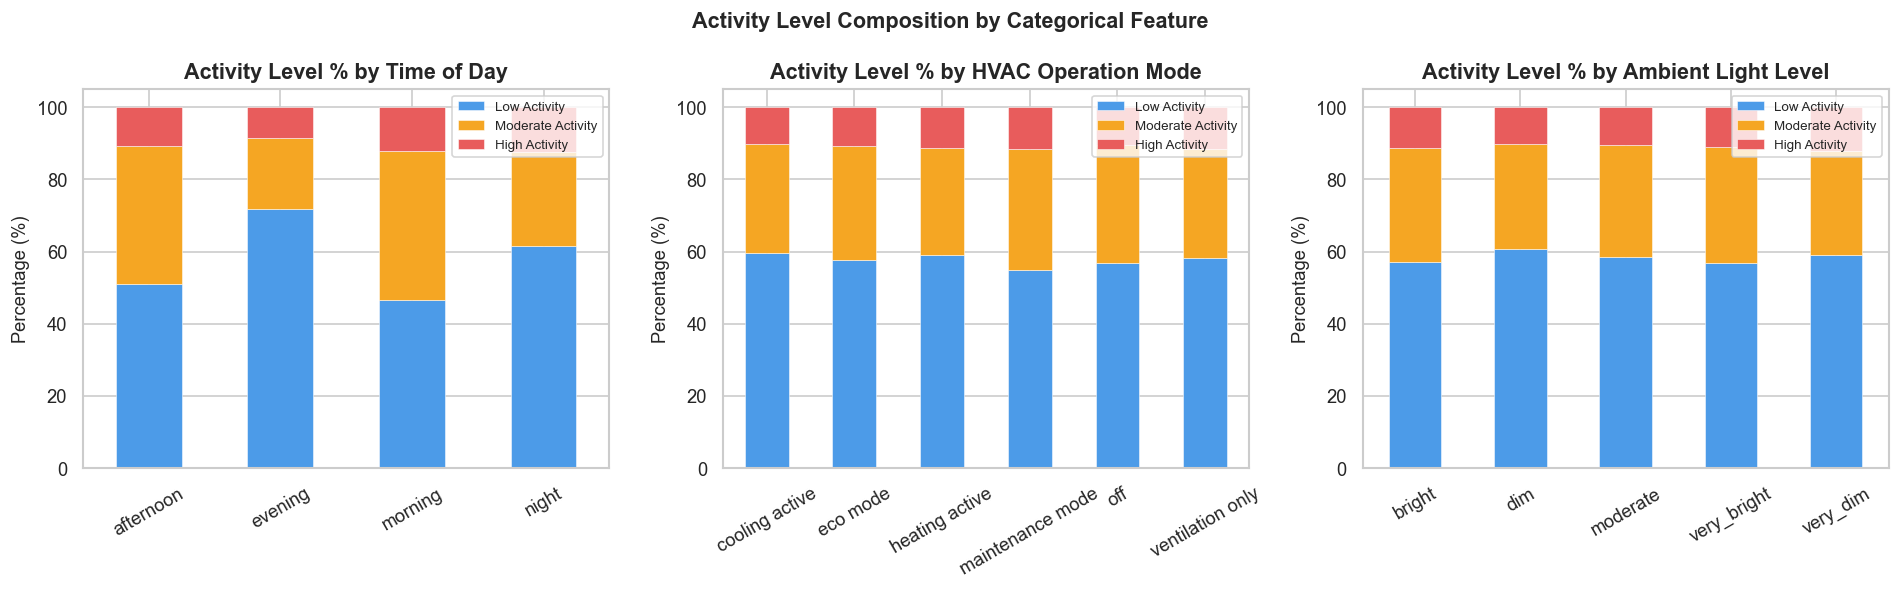

In [13]:
# Stacked bar: what % of each category belongs to each activity class
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, cat_cols):
    ct = (
        pd.crosstab(df_clean[col], df_clean["Activity Level"], normalize="index")
        [CLASS_ORDER] * 100
    )
    ct.plot(
        kind="bar", stacked=True, ax=ax,
        color=[PALETTE[c] for c in ct.columns],
        edgecolor="white", linewidth=0.3
    )
    ax.set_title(f"Activity Level % by {col}", fontweight="bold")
    ax.set_ylabel("Percentage (%)")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)
    ax.legend(fontsize=8, loc="upper right")

plt.suptitle("Activity Level Composition by Categorical Feature", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

**Findings:**
- `Time of Day`: Night periods lean toward Low Activity — people are less active at night. Morning and afternoon have a slightly higher share of High Activity.
- `HVAC Operation Mode`: Activity composition shifts slightly across modes but no single mode dominates — a supporting feature, not a strong predictor alone.
- `Ambient Light Level`: Brighter environments tend to have more Moderate and High Activity, which is intuitive — active periods happen when the room is lit.
- These patterns are not strong enough to predict activity on their own, but they add useful **context** alongside the sensor readings.


### 6.3 Sensor Correlation Heatmap


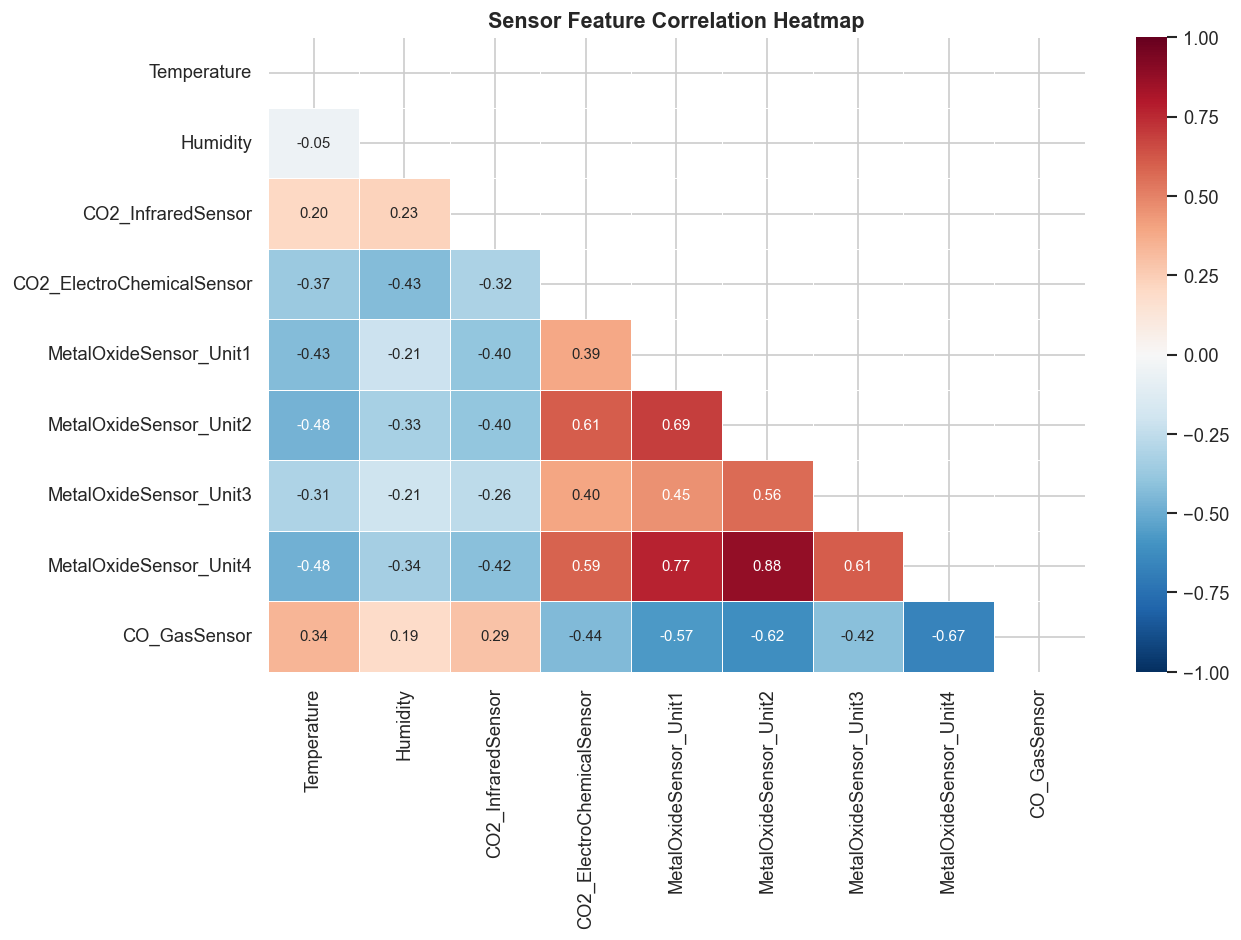

In [14]:
# Lower-triangle heatmap to check for multicollinearity between sensor features
corr_matrix = df_clean[sensor_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # hide upper triangle (duplicate)

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt=".2f",
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax, annot_kws={"size": 9}
)
ax.set_title("Sensor Feature Correlation Heatmap", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

**Findings:**
- `CO2_InfraredSensor` and `CO2_ElectroChemicalSensor` are strongly correlated — they measure the same gas. This redundancy justifies averaging them into a single `CO2_Average` feature.
- The 4 Metal Oxide sensors are moderately correlated with each other but not identical, so all 4 are kept initially. Summing them into `TotalMOS` captures the combined VOC signal.
- Temperature and Humidity have weaker correlations with the gas sensors.


---
## 7. Feature Engineering

**Purpose:** Create new features that combine or transform raw sensor readings to give the model more useful signal. Each feature is justified and validated against the target before keeping it.


In [15]:
#Engineered features

# 1. CO2_Average — averages the two correlated CO2 sensors to reduce noise
#    Justified by: strong correlation between IR and ElectroChemical sensors (see heatmap)
df_clean["CO2_Average"] = (
    df_clean["CO2_InfraredSensor"] + df_clean["CO2_ElectroChemicalSensor"]
) / 2

# 2. TotalMOS — sums all 4 Metal Oxide Sensor units into one overall VOC signal
#    Justified by: MOS units are the top individual predictors; their sum captures combined gas load
df_clean["TotalMOS"] = (
    df_clean["MetalOxideSensor_Unit1"] + df_clean["MetalOxideSensor_Unit2"] +
    df_clean["MetalOxideSensor_Unit3"] + df_clean["MetalOxideSensor_Unit4"]
)

# 3. CO2_CO_Ratio — ratio of CO2 to CO signal; captures relative respiration vs combustion
#    +1 in denominator avoids division by zero
df_clean["CO2_CO_Ratio"] = df_clean["CO2_Average"] / (df_clean["CO_GasSensor"] + 1)

# 4. TimeOfDay_Ordinal — ordinal encoding of time period for models that benefit from order
#    Order: night(0) < morning(1) < afternoon(2) < evening(3)
time_order = {"night": 0, "morning": 1, "afternoon": 2, "evening": 3}
df_clean["TimeOfDay_Ordinal"] = df_clean["Time of Day"].map(time_order)

print("Engineered features added:")
df_clean[["CO2_Average", "TotalMOS", "CO2_CO_Ratio", "TimeOfDay_Ordinal", "Activity Level"]].head(5)

Engineered features added:


,CO2_Average,TotalMOS,CO2_CO_Ratio,TimeOfDay_Ordinal,Activity Level
0,348.288,"2,434.083",116.096,1,Low Activity
1,351.066,"2,445.051",175.533,1,Low Activity
2,356.052,"2,450.701",178.026,1,Low Activity
3,355.477,"2,535.535",177.739,1,High Activity
4,353.211,"2,651.935",176.605,1,Low Activity


C:\Users\mingh\AppData\Local\Temp\ipykernel_4972\2640030107.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\mingh\AppData\Local\Temp\ipykernel_4972\2640030107.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\mingh\AppData\Local\Temp\ipykernel_4972\2640030107.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


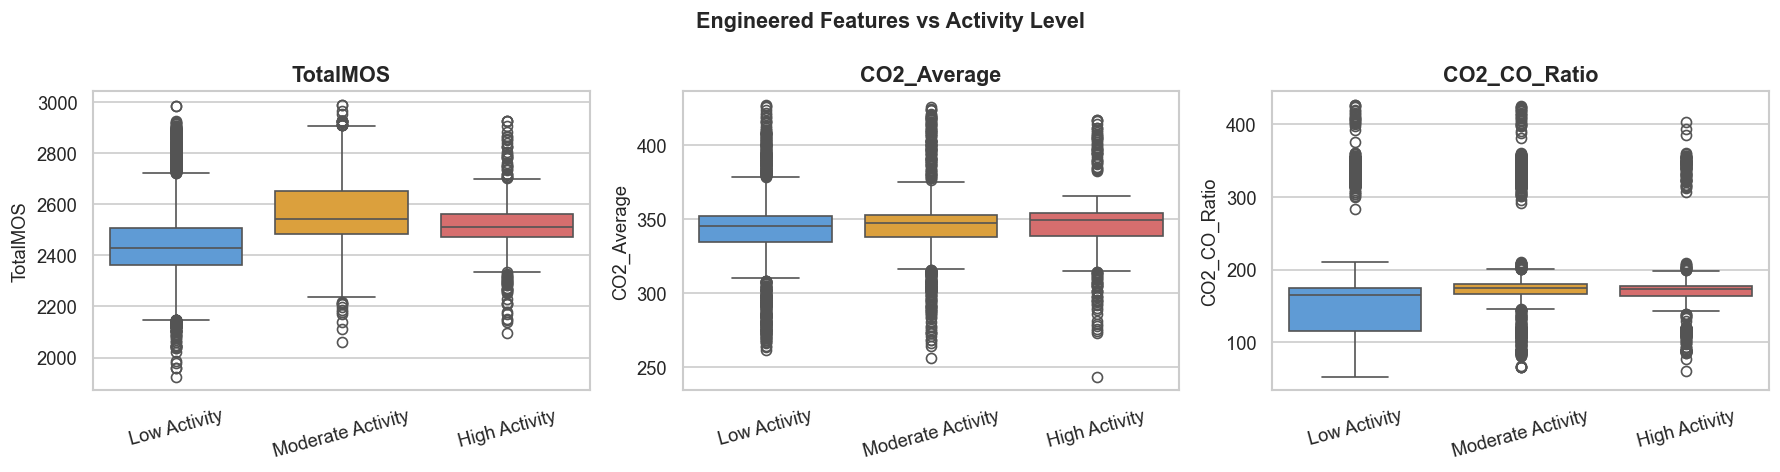

In [16]:
# Validate: do the engineered features actually separate activity classes?
eng_features = ["TotalMOS", "CO2_Average", "CO2_CO_Ratio"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, eng_features):
    sns.boxplot(
        data=df_clean, x="Activity Level", y=col,
        order=CLASS_ORDER, palette=PALETTE, ax=ax
    )
    ax.set_title(col, fontweight="bold")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=15)

plt.suptitle("Engineered Features vs Activity Level", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

**Findings:**

| Feature | Justification | Validation result |
|---|---|---|
| `CO2_Average` | Reduces noise from two correlated CO2 sensors | Clear median increase from Low → High Activity |
| `TotalMOS` | Combines the strongest sensor family into one signal | Strongest class separation of all engineered features |
| `CO2_CO_Ratio` | Captures relative respiration vs combustion balance | Moderate separation — keep and validate during model tuning |
| `TimeOfDay_Ordinal` | Ordered encoding for models that use feature magnitude | Used alongside one-hot encoding for flexibility |

> `TotalMOS` shows the clearest class separation and is the most justified engineered feature. `CO2_CO_Ratio` is more experimental — it will only be kept if it improves validation performance.


---
## 8. Summary & Pipeline Handoff

### Cleaning decisions

| Issue | What was found | What the pipeline should do |
|---|---|---|
| Dirty `Activity Level` labels | 6 raw variants → 3 real classes | Map using `activity_map` dictionary |
| Dirty `HVAC Operation Mode` labels | 23 raw variants → 6 real modes | Lowercase + strip + replace underscores |
| Mixed temperature units | 795 rows recorded in Kelvin (289–307 K) | Convert to Celsius (subtract 273.15); impute any remaining out-of-range values |
| Impossible humidity readings | 414 rows outside 0–100% | Set to NaN, then median-impute |
| Missing numerical values | 4 columns, 8–19% missing | Median imputation (fit on train only) |
| Missing categorical values | `Ambient Light Level` 10.5% | Mode imputation (fit on train only) |
| Class imbalance | High Activity = 10.9% | Stratified split, weighted F1, try SMOTE |
| `Session ID` | Identifier column | Drop before training |

### Features expected to matter most
1. `TotalMOS` (engineered) and `MetalOxideSensor_Unit2`, `MetalOxideSensor_Unit4`
2. `CO2_ElectroChemicalSensor` and `CO2_Average` (engineered)
3. `CO_GasSensor` — useful inverse signal
4. `Time of Day` and `Ambient Light Level` — supporting context

### Metrics to report
| Metric | Why |
|---|---|
| **Weighted F1** | Primary metric — accounts for class imbalance |
| **Macro F1** | Checks minority class is not being ignored |
| **High Activity Recall** | Ensures rare but important class is detected |
| **Confusion Matrix** | Shows exactly where the model confuses classes |



In [17]:
# Final summary
print("=== EDA Complete ===")
print(f"Raw dataset      : {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
print(f"Clean dataset    : {df_clean.shape[0]:,} rows x {df_clean.shape[1]} columns")
print(f"Target classes   : {sorted(df_clean['Activity Level'].unique())}")
print(f"Missing values   : {df_clean.isnull().sum().sum()}")
print()
print("Columns to drop before training: ['Session ID', 'Activity Level']")
print("Engineered features added      : ['CO2_Average', 'TotalMOS', 'CO2_CO_Ratio', 'TimeOfDay_Ordinal']")

=== EDA Complete ===
Raw dataset      : 10,000 rows x 14 columns
Clean dataset    : 10,000 rows x 18 columns
Target classes   : ['High Activity', 'Low Activity', 'Moderate Activity']
Missing values   : 0

Columns to drop before training: ['Session ID', 'Activity Level']
Engineered features added      : ['CO2_Average', 'TotalMOS', 'CO2_CO_Ratio', 'TimeOfDay_Ordinal']


---
## 9. Conclusion

### Summary of EDA findings

This EDA examined 10,000 rows and 14 columns from the gas monitoring dataset, with the goal of predicting `Activity Level` (Low, Moderate, or High) from sensor readings and contextual features. Several data quality issues were identified and resolved before any modelling decisions were made.

---

### How missing values were handled

Four columns contained missing values (8.3%–19.3%). Numeric columns (`Humidity`, `MetalOxideSensor_Unit2`, `CO_GasSensor`) were imputed with the **column median** because extreme sensor readings make the mean unreliable. The categorical column (`Ambient Light Level`) was imputed with the **mode**. Temperature readings in the Kelvin range (289–307 K) were **converted to Celsius** (subtract 273.15) rather than discarded — they represent valid indoor temperatures (~16–34°C). Any remaining out-of-range temperature values and out-of-range humidity values were set to NaN and median-imputed. In the ML pipeline, imputers are fitted **only on training data** to prevent data leakage.

---

### Best visualisation method and justification

The **box plot grouped by Activity Level** (Section 6.1) was the most informative visualisation in this EDA. Because the task is a 3-class classification problem, the key question at every step is whether a feature's values differ meaningfully across the three classes. Box plots show the median, spread, and outliers for each class side-by-side, making it easy to see which features separate Low, Moderate, and High Activity. This directly informed feature selection and justified the engineered features.

Other visualisations and their roles:
- **Horizontal bar chart** (missing values): quick comparison of missingness % across columns
- **KDE plots with mean/median lines** (sensor distributions): revealed skewness and confirmed cleaning worked
- **Count bar charts** (categorical features): showed frequency and class distribution per category
- **Stacked bar charts** (categorical vs Activity Level): confirmed categorical features as supporting predictors
- **Correlation heatmap**: identified redundant features (two CO2 sensors) and justified engineered `CO2_Average`

---

### Overall conclusion

The Metal Oxide sensors (Units 2 and 4) and `CO2_ElectroChemicalSensor` are the strongest individual predictors. The engineered feature `TotalMOS` consolidates the MOS(metal oxide sensor) signal and shows good class separation. Class imbalance (High Activity at only 10.9%) means accuracy alone is misleading — the pipeline uses **weighted F1** as the primary metric, with **macro F1** and the **confusion matrix** reported alongside to ensure the minority class is not being ignored.
